In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
cosmic_df = pd.read_csv("KCNA5_T1_mutations.csv")

In [ ]:
ddg_df_AD = pd.read_csv("results/Binding_DDG_AD.csv",sep=",")
ddg_df_AD.loc[:, "MUT_pos"] = [int(mutation[2:-1]) for mutation in ddg_df_AD["Mutation"]]
ddg_df_AD.loc[:, "Mutation"] = [mutation[0]+str(int(mutation[2:-1]))+mutation[-1] for mutation in ddg_df_AD["Mutation"]]
ddg_df_AD = ddg_df_AD.assign(Chain="A")

In [ ]:
ddg_df_DA = pd.read_csv("results/Binding_DDG_DA.csv",sep=",")
ddg_df_DA.loc[:, "MUT_pos"] = [int(mutation[2:-1]) for mutation in ddg_df_DA["Mutation"]]
ddg_df_DA.loc[:, "Mutation"] = [mutation[0]+str(int(mutation[2:-1]))+mutation[-1] for mutation in ddg_df_DA["Mutation"]]
ddg_df_DA = ddg_df_DA.assign(Chain="D")

In [6]:
ddg_df = pd.concat([ddg_df_AD,ddg_df_DA])
ddg_df = ddg_df.iloc[:, [0,5, 4, 1, 2,3]].sort_values('MUT_pos')

In [ ]:
# Extracts rows with non-zero ddg
ddg_df_non_zero = ddg_df[np.abs(ddg_df["DDG"])>=0.8]

In [8]:
sign_mut = set(ddg_df_non_zero.loc[:, "Mutation"])
cosmic_df_filtered = cosmic_df[cosmic_df["Mutation"].isin(sign_mut)]
ddg_df_filtered = ddg_df[ddg_df["Mutation"].isin(cosmic_df_filtered["Mutation"])]

In [9]:
ddg_df_cosmic = ddg_df[ddg_df["Mutation"].isin(cosmic_df["Mutation"])]

/tmp/ipykernel_8871/356406373.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0, 0.5, 'Density')

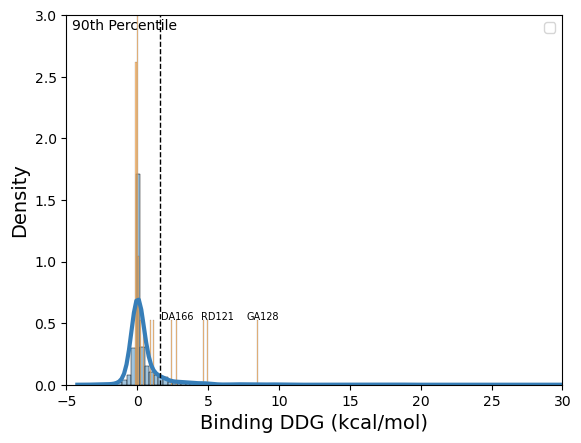

In [ ]:
ax = sns.histplot(
    ddg_df["DDG"],
    bins=100,
    stat="density",
    kde=False,
    color=sns.color_palette("Set3")[4]
)

sns.kdeplot(
    ddg_df["DDG"],
    bw_method=0.25,
    color=sns.color_palette("Set1")[1],
    alpha=1,
    legend=False,
    lw=3,
    ax=ax
)

sns.histplot(
    ddg_df_cosmic["DDG"],
    bins=100,
    stat="density",
    kde=False,
    color=sns.color_palette("Set3")[5],
    ax=ax
)

p95 = ddg_df["DDG"].quantile(0.95)
p90 = ddg_df["DDG"].quantile(0.9)

ax.text(
    2.8,
    ax.get_ylim()[1] * 0.9,
    "90th Percentile",
    verticalalignment="top",
    horizontalalignment="right"
)

ax.axvline(
    p90,
    color="black",
    lw=1,
    linestyle="--"
)

ax.text(
    4,
    ax.get_ylim()[1] * 0.18,
    "DA166",
    verticalalignment="top",
    horizontalalignment="right",
    fontsize=7,
)

ax.text(
    6.8,
    ax.get_ylim()[1] * 0.18,
    "RD121",
    verticalalignment="top",
    horizontalalignment="right",
    fontsize=7,
)


ax.text(
    10,
    ax.get_ylim()[1] * 0.18,
    "GA128",
    verticalalignment="top",
    horizontalalignment="right",
    fontsize=7,
)

ax.set_xlim(-5,30)
ax.set_ylim(0,3)
ax.set_xlabel("Binding DDG (Kcal/mol)", size=14)
ax.set_xlabel("Binding DDG (kcal/mol)", fontsize=14)
ax.set_ylabel("Density", fontsize=14)

